In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def getMooreCounts(array, boundaries = 'periodic'):
    """
    Compute counts of each state in the Moore neighborhood for each cell in the input 2D array.

    Parameters
    ----------
    array : 2D numpy array
        Input grid where each cell contains an integer state.
    boundaries : str, optional
        Type of boundary conditions to apply. Currently supports 'periodic' (default).

    Returns
    -------
    numpy.ndarray
        A 2D array of shape (N, n_states + 1) where N is the total number of cells in the grid and n_states is the maximum state value in the input array. The first column contains the original cell states, and the subsequent columns contain the counts of each state in the Moore neighborhood.
    """
    # n_states = np.max(array) + 1

    N            = array.size
    result       = np.zeros((N, 4), dtype=int)
    result[:, 0] = array.ravel()

    if boundaries == 'periodic':

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue

                shifted = np.roll(np.roll(array, dx, axis=0), dy, axis=1)
                
                for s in range(3):
                    result[:, s + 1] += (shifted == s).ravel()

    return result 

###########################
# Deterministic Rules
###########################

def autocatalysis(neighborhood):
    """
    Reads a neighborhood array with the following structure:

    Cell state | Number of zeros | Number of ones | Number of twos
    [     0              2                 5               1        ]
    [     1              3                 4               1        ]
    [                            ...                                ]
    [     2              1                 6               1        ]

    Shape: N x 4, where N is the total number of cells in the grid.

    The function turns the achiral cells (state 0) into chiral cells (state 1 or 2)
    if the number of chiral neighbors (state 1 and state 2) is greater than the number
    of achiral neighbors (state 0). If the number of achiral neighbors is equal to the
    number of chiral neighbors, the cell state remains unchanged.

    It returns an array of new states for each cell in the grid.
    """
    new_states = []

    for state, number_of_zeros, number_of_ones, number_of_twos in neighborhood:
        if state == 0 and number_of_zeros < (number_of_ones + number_of_twos):
            if number_of_ones > number_of_twos:
                new_states.append(1)
            elif number_of_twos > number_of_ones:
                new_states.append(2)
            else:
                new_states.append(state)
        else:
            new_states.append(state)

    return np.array(new_states)

def mutualInhibition(neighborhood):
    """
    Reads a neighborhood array with the following structure:

    Cell state | Number of zeros | Number of ones | Number of twos
    [     0              2                 5               1        ]
    [     1              3                 4               1        ]
    [                            ...                                ]
    [     2              1                 6               1        ]

    Shape: N x 4, where N is the total number of cells in the grid.

    The funcion turns the chiral cells (state 1 or 2) into achiral cells (state 0)
    if the neighborhood contains a majority of cells with the opposite chirality.
    If the number of cells with the opposite chirality is equal to the number of cells
    with the same chirality, the cell state remains unchanged.

    It returns an array of new states for each cell in the grid.
    """
    new_states = []

    for state, number_of_zeros, number_of_ones, number_of_twos in neighborhood:
        if state == 1 and (number_of_zeros + number_of_ones) < number_of_twos:
            new_states.append(0)
        elif state == 2 and (number_of_zeros + number_of_twos) < number_of_ones:
            new_states.append(0)
        else:
            new_states.append(state)

    return np.array(new_states)

########################
# Stochastic Rules
########################

def spontaneusNeutrality(epsilon, p_neutral, neighborhood):
    """
    Reads a neighborhood array with the following structure:

    Cell state | Number of zeros | Number of ones | Number of twos
    [     0              2                 5               1        ]
    [     1              3                 4               1        ]
    [                            ...                                ]
    [     2              1                 6               1        ]

    Shape: N x 4, where N is the total number of cells in the grid.

    The function turns the chiral cells (state 1 or 2) into achiral cells (state 0)
    with a probability p_neutral, regardless of the neighborhood composition.
    p_neutral is modulared by the parameter epsilon, which represents the strength
    of the stochastic effect.

    It returns an array of new states for each cell in the grid.
    """
    new_states = []
    prob = epsilon * p_neutral

    for state, number_of_zeros, number_of_ones, number_of_twos in neighborhood:
        if state in [1, 2]:
            rand = np.random.rand()  # uses uniform distribution (change for lognormal?)
            if rand < prob:
                new_states.append(0)
            else:
                new_states.append(state)
        else:
            new_states.append(state)

    return np.array(new_states)

def spontaneousChirality(epsilon, p_chiral, neighborhood):
    """
    Reads a neighborhood array with the following structure:

    Cell state | Number of zeros | Number of ones | Number of twos
    [     0              2                 5               1        ]
    [     1              3                 4               1        ]
    [                            ...                                ]
    [     2              1                 6               1        ]

    Shape: N x 4, where N is the total number of cells in the grid.

    The function turns the achiral cells (state 0) into chiral cells (state 1 or 2)
    with a probability p_chiral, regardless of the neighborhood composition.
    p_chiral is modulared by the parameter epsilon, which represents the strength
    of the stochastic effect.

    It returns an array of new states for each cell in the grid.
    """
    new_states = []
    prob = epsilon * p_chiral

    for state, number_of_zeros, number_of_ones, number_of_twos in neighborhood:
        if state == 0:
            rand = np.random.rand()  # uses uniform distribution
            if rand < prob:
                new_states.append(1 if np.random.rand() < 0.5 else 2)  # 50% chance to become 1 or 2
            else:
                new_states.append(state)
        else:
            new_states.append(state)

    return np.array(new_states)

def diffusion(epsilon, p_copy, neighborhood):
    """
    Reads a neighborhood array with the following structure:

    Cell state | Number of zeros | Number of ones | Number of twos
    [     0              2                 5               1        ]
    [     1              3                 4               1        ]
    [                            ...                                ]
    [     2              1                 6               1        ]

    Shape: N x 4, where N is the total number of cells in the grid.

    The function allows a cell to copy one of its neighbors' states with a
    probability p_copy, regardless of the neighborhood composition.
    p_copy is modulared by the parameter epsilon, which represents the strength
    of the stochastic effect.

    It returns an array of new states for each cell in the grid.
    """
    new_states = []
    prob = epsilon * p_copy

    for state, number_of_zeros, number_of_ones, number_of_twos in neighborhood:
        rand = np.random.rand()  # uses uniform distribution
        if rand < prob:
            neighbors_states = [0]*number_of_zeros + [1]*number_of_ones + [2]*number_of_twos
            new_states.append(np.random.choice(neighbors_states))  # also uses uniform distribution but can be changed
        else:
            new_states.append(state)

    return np.array(new_states)


In [84]:
np.random.seed(0)
SIZE = (64, 64)

# 1. Random uniform — equal probability of all three states
ic_random = np.random.choice([0, 1, 2], size=SIZE)

# 2. Chiral seed — all achiral except a small central patch of state 1
ic_seed = np.zeros(SIZE, dtype=int)
cx, cy = SIZE[0] // 2, SIZE[1] // 2
ic_seed[cx-3:cx+3, cy-3:cy+3] = 1

# 3. Symmetric competition — left half state 1, right half state 2
ic_competition = np.ones(SIZE, dtype=int)
ic_competition[:, SIZE[1] // 2:] = 2

# 4. Achiral majority — 90% state 0, 5% state 1, 5% state 2
ic_achiral_majority = np.random.choice([0, 1, 2], size=SIZE, p=[0.90, 0.05, 0.05])

initial_conditions = {
    'Random Uniform'     : ic_random,
    'Chiral Seed'        : ic_seed,
    'Symmetric Competition': ic_competition,
    'Achiral Majority'   : ic_achiral_majority,
}


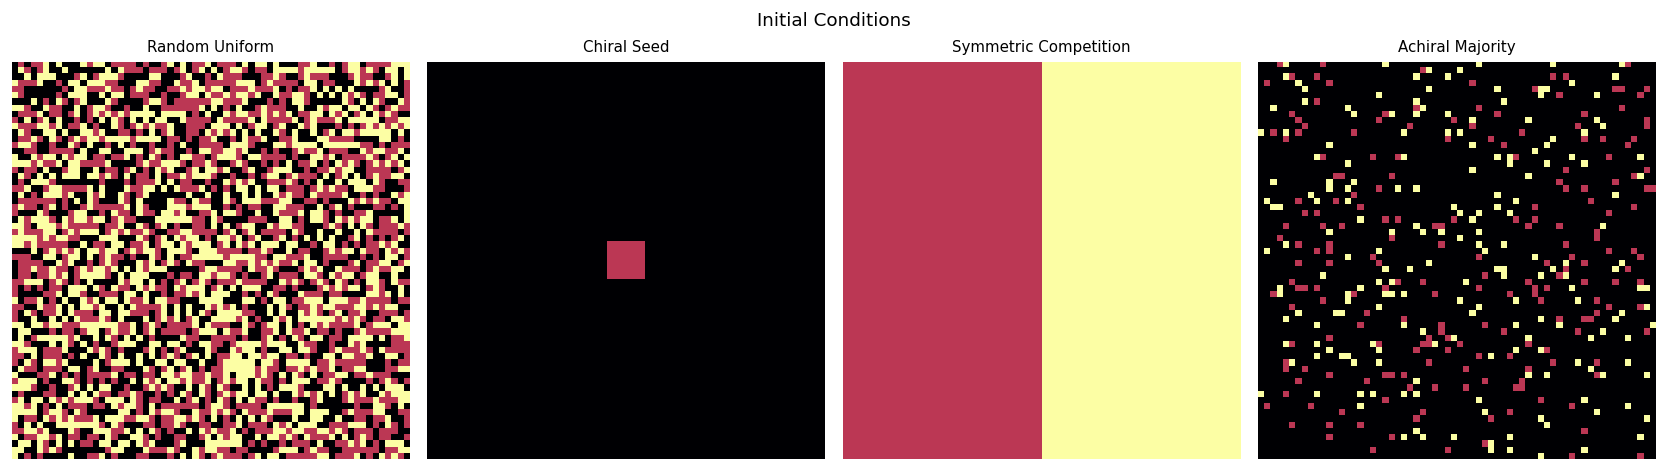

In [85]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), dpi=120)

for ax, (name, ic) in zip(axes, initial_conditions.items()):
    ax.imshow(ic, cmap='inferno', vmin=0, vmax=2)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.suptitle('Initial Conditions', fontsize=11)
plt.tight_layout()
plt.show()


In [100]:
# Choose initial condition: 'Random Uniform', 'Chiral Seed', 'Symmetric Competition', 'Achiral Majority'
INITIAL_CONDITION = 'Achiral Majority'

max_steps = 100
epsilon   = 1.0
p_neutral = 0.1
p_chiral  = 0.1
p_copy    = 0.8

list_of_0s = []
list_of_1s = []
list_of_2s = []

data = initial_conditions[INITIAL_CONDITION].copy()

# Save the initial state counts
unique, counts = np.unique(data, return_counts=True)
count_dict = dict(zip(unique, counts))
list_of_0s.append(count_dict.get(0, 0))
list_of_1s.append(count_dict.get(1, 0))
list_of_2s.append(count_dict.get(2, 0))

for step in range(max_steps):

    neighborhood = getMooreCounts(data)
    grid = autocatalysis(neighborhood).reshape(data.shape)

    neighborhood = getMooreCounts(grid)
    grid = mutualInhibition(neighborhood).reshape(data.shape)

    neighborhood = getMooreCounts(grid)
    grid = spontaneusNeutrality(epsilon, p_neutral, neighborhood).reshape(data.shape)

    neighborhood = getMooreCounts(grid)
    grid = spontaneousChirality(epsilon, p_chiral, neighborhood).reshape(data.shape)

    neighborhood = getMooreCounts(grid)
    grid = diffusion(epsilon, p_copy, neighborhood).reshape(data.shape)

    data = grid

    unique, counts = np.unique(grid, return_counts=True)
    count_dict = dict(zip(unique, counts))
    list_of_0s.append(count_dict.get(0, 0))
    list_of_1s.append(count_dict.get(1, 0))
    list_of_2s.append(count_dict.get(2, 0))


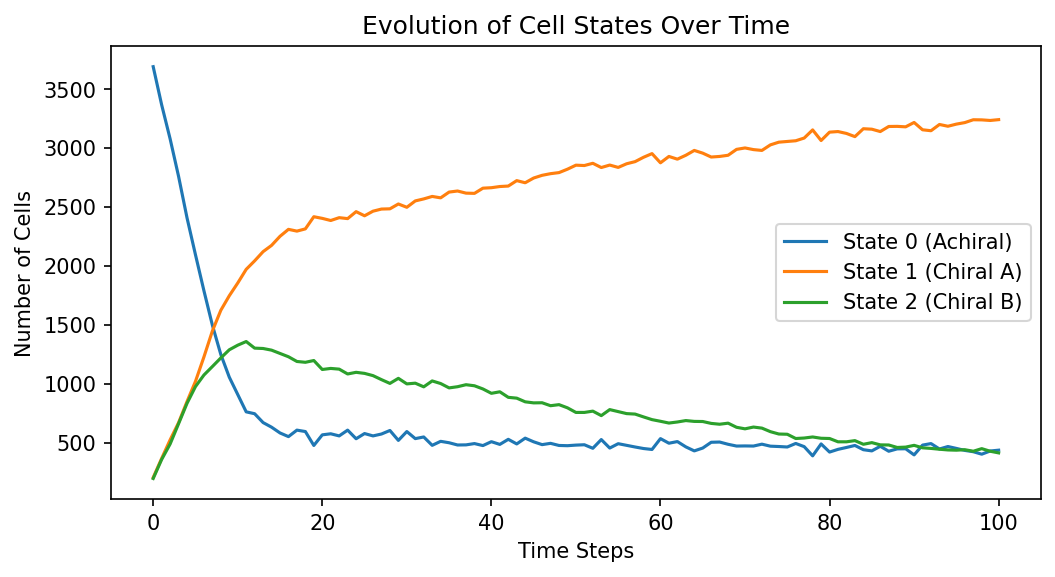

In [101]:
# All three states coexist
plt.figure(figsize=(8,4), dpi=150)
plt.plot(list_of_0s, label='State 0 (Achiral)')
plt.plot(list_of_1s, label='State 1 (Chiral A)')
plt.plot(list_of_2s, label='State 2 (Chiral B)')
plt.xlabel('Time Steps')
plt.ylabel('Number of Cells')
plt.title('Evolution of Cell States Over Time')
# plt.ylim(0)
plt.legend()
plt.show()